# 03 客户分层评分：有限的外呼资源该优先打给谁？

## 业务问题

1. 用**外呼前已知的信息**（人口统计 + 历史痕迹 + 联系时点），能否给每个客户打一个"转化潜力分"？
2. 按潜力分从高到低联系客户，**联系最头部的多少%客户，能捕获多少%的总转化量**（Gains Chart）？
3. 什么样的客户在评分里"值钱"（系数方向与大小）？

> 评分目的：**外呼优先级排序**，不是因果推断——本 notebook 不声称任何特征"导致"转化，只度量"已知信息对转化潜力的判别力"（沿用 02 的关联≠因果口径）。渠道的因果问题在 notebook 04 用 PSM 处理，本 notebook **不使用 `contact` 作为评分特征**：渠道是决策变量而非客户属性，把渠道烤进潜力分会与 04 的渠道分析循环论证。

## 口径与方法假设定义

### 特征集：外呼前已知信息（三组约束共同收紧）

1. **duration 禁用**（00 文档声明一）：通话时长在拨号前不存在，任何外呼前模型不得使用；
2. **时间代理只用 `month`**（00 文档 §2.6 决策）：五个宏观变量（`euribor3m`/`emp.var.rate`/`nr.employed`/`cons.price.idx`/`cons.conf.idx`）VIF 高达 63.9/32.9/30.7，全部是采集时间的代理且互为共线，统一剔除，仅保留可解释的 `month`；
3. **`contact` 不进评分**（上文业务问题）：渠道是决策变量，留给 04。

> **无客户唯一 ID 边界**（00 文档 §2.1）：本数据集每行是一次外呼活动记录，`pdays_bucket`/`poutcome`/`previous` 是“当前活动记录里的历史痕迹”，不是跨活动纵向追踪的产物；`pdays=999` 不代表“从未联系”（见 01 的哨兵值发现）。评分模型按行独立打分，不依赖纵向追踪，但历史痕迹类排序特征的解读仍需注意这一边界。

入选特征：`age`、`job`、`marital`、`education`、`default`、`housing`、`loan`（人口统计）+
`month`、`day_of_week`（联系时点）+ `previous`、`pdays_bucket`、`poutcome`（历史痕迹）+ `campaign`（本次已尝试次数）。

### campaign 的使用边界（沿用 00 文档声明四）

`campaign` 是"本次已拨打次数"，拨号时已知，且是强判别信号；但它同时是**销售主观判断的结果**（反向因果）。本 notebook 把它作为**排序特征**使用（描述性判别），属于"把历史观察用于优先级排序"的正当用途；**绝不把它解读为"多打几次电话能提高转化"**——那是因果声称，数据支撑不了（描述性边际关系见 notebook 05）。

### 模型与评估方法

- **模型**：LogisticRegression（`class_weight='balanced'` 处理 11%:89% 的类别不平衡），OneHot 编码分类变量（`drop='first'`，`unknown` 保留为独立类别）、数值变量标准化；
- **评估**：StratifiedKFold(5) 的 **OOF（out-of-fold）预测概率**做评估——OOF 概率来自未参与训练的折，避免过拟合乐观偏差；
- **指标**：**AUC**（对类别不平衡稳健，不用 Accuracy——全预测"否"就有 88.7% Accuracy）+ **Gains Chart**（按 OOF 概率降序联系客户，累计捕获转化量的比例）+ **Lift**；
- 报告各分位点（Top 1%/5%/10%/20%/30%/50%/80%/100%）的捕获率，并与随机基线（联系 N% 客户捕获 N% 转化）对比。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 定位项目根目录并加入模块搜索路径（与前序 notebook 相同的启动逻辑）
_CWD = Path.cwd()
_PROBE = Path("src") / "telemarketing_utils.py"
if not (_CWD / _PROBE).exists() and (_CWD.parent / _PROBE).exists():
    sys.path.insert(0, str(_CWD.parent))
else:
    sys.path.insert(0, str(_CWD))

from src.telemarketing_utils import find_project_root, setup_plot_style  # noqa: E402

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-additional-full.csv"
REPORT_DIR = PROJECT_ROOT / "reports"

setup_plot_style()
import matplotlib.pyplot as plt  # noqa: E402

df = pd.read_csv(DATA_PATH, sep=";")
print("总样本:", len(df))

总样本: 41188


In [2]:
# 特征集声明与约束自检
NUMERIC_FEATURES = ["age", "campaign", "previous"]
CATEGORICAL_FEATURES = ["job", "marital", "education", "default", "housing", "loan",
                        "month", "day_of_week", "poutcome", "pdays_bucket"]

# pdays 分桶（与 01/02 口径一致）
df["pdays_bucket"] = pd.cut(
    df["pdays"], bins=[-1, 0, 3, 7, 14, 27, 999],
    labels=["=0天", "1-3天", "4-7天", "8-14天", "15-27天", "999（从未/不可考）"],
).astype(str)

EXCLUDED = {"duration", "contact",
            "euribor3m", "emp.var.rate", "nr.employed", "cons.price.idx", "cons.conf.idx"}
assert not (set(NUMERIC_FEATURES + CATEGORICAL_FEATURES) & EXCLUDED), "禁用字段不得进入特征集"
print("✓ duration、contact、五个宏观变量均已排除")
print("✓ 时间代理仅保留 month（00 文档 §2.6 决策）")
print(f"特征集：数值 {NUMERIC_FEATURES}；类别 {CATEGORICAL_FEATURES}")

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = (df["y"] == "yes").astype(int)
print("正类占比: {:.2%}".format(y.mean()))

✓ duration、contact、五个宏观变量均已排除
✓ 时间代理仅保留 month（00 文档 §2.6 决策）
特征集：数值 ['age', 'campaign', 'previous']；类别 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'day_of_week', 'poutcome', 'pdays_bucket']
正类占比: 11.27%


In [3]:
preprocessor = ColumnTransformer([
    ("c", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL_FEATURES),
    ("n", StandardScaler(), NUMERIC_FEATURES),
])

model = Pipeline([
    ("pre", preprocessor),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

# OOF 预测：StratifiedKFold 5 折，每折用未参与训练的样本预测
oof = np.zeros(len(X))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, te_idx in skf.split(X, y):
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof[te_idx] = model.predict_proba(X.iloc[te_idx])[:, 1]

auc_oof = roc_auc_score(y, oof)
print(f"OOF AUC = {auc_oof:.4f}")
print("（随机基线 AUC = 0.5；越接近 1 判别力越强）")

OOF AUC = 0.7403
（随机基线 AUC = 0.5；越接近 1 判别力越强）


In [4]:
# Gains Chart：按 OOF 潜力分降序联系客户，累计捕获转化量
order = np.argsort(-oof)
sorted_y = y.iloc[order].values
cum_yes = np.cumsum(sorted_y)
total_yes = y.sum()

percentiles = [1, 5, 10, 20, 30, 50, 80, 100]
gains_rows = []
for pct in percentiles:
    n_top = max(int(len(y) * pct / 100), 1)
    captured = cum_yes[n_top - 1] / total_yes
    lift = captured / (pct / 100)
    gains_rows.append({"联系客户占比%": pct, "捕获转化量占比%": round(captured, 4),
                       "Lift(相对随机)": round(lift, 2)})
gains_tab = pd.DataFrame(gains_rows)
gains_tab

,联系客户占比%,捕获转化量占比%,Lift(相对随机)
0,1,0.0631,6.31
1,5,0.2571,5.14
2,10,0.4017,4.02
3,20,0.5399,2.70
4,30,0.6144,2.05
5,50,0.7528,1.51
6,80,0.9216,1.15
7,100,1.0000,1.00


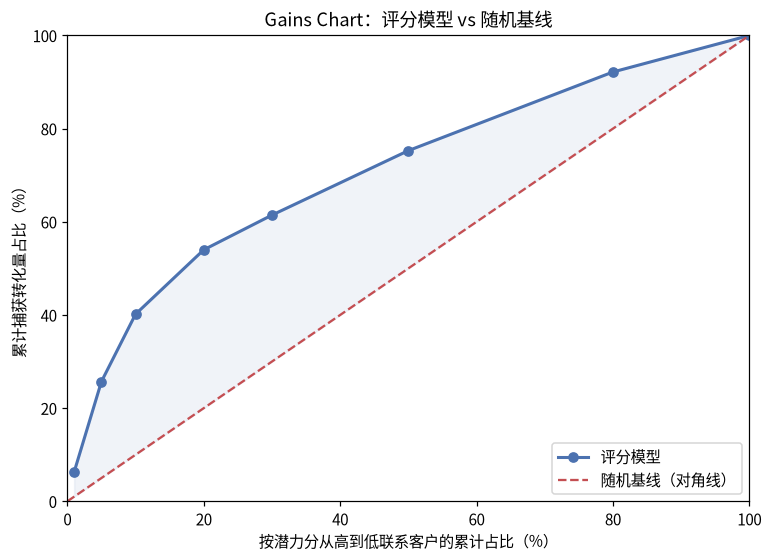

In [5]:
# Gains Chart 可视化
fig, ax = plt.subplots(figsize=(8, 5.5))
g = gains_tab.set_index("联系客户占比%")
ax.plot(g.index, g["捕获转化量占比%"] * 100, "o-", color="#4C72B0", lw=2, label="评分模型")
ax.plot([0, 100], [0, 100], "--", color="#C44E52", lw=1.5, label="随机基线（对角线）")
ax.fill_between(g.index, g.index, g["捕获转化量占比%"] * 100, interpolate=True, color="#4C72B0", alpha=0.08)
ax.set_xlabel("按潜力分从高到低联系客户的累计占比（%）")
ax.set_ylabel("累计捕获转化量占比（%）")
ax.set_title("Gains Chart：评分模型 vs 随机基线")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(loc="lower right")
plt.savefig(REPORT_DIR / "03_gains_chart.png", bbox_inches="tight")
plt.show()

In [6]:
# 关键系数（在全量数据上重训一次，仅供解释方向与大小，不参与评估）
model.fit(X, y)
coefs = model.named_steps["lr"].coef_[0]
cat_names = model.named_steps["pre"].named_transformers_["c"].get_feature_names_out().tolist()
all_names = cat_names + NUMERIC_FEATURES
coef_df = pd.DataFrame({"特征": all_names, "系数": coefs})
coef_df["|系数|"] = coef_df["系数"].abs()
coef_df = coef_df.sort_values("|系数|", ascending=False)
print("绝对值最大的 12 个系数（方向即与转化潜力的正/负关系）：")
coef_df.head(12).round(3)

绝对值最大的 12 个系数（方向即与转化潜力的正/负关系）：


,特征,系数,|系数|
45,pdays_bucket_999（从未/不可考）,-1.490,1.490
31,month_mar,1.167,1.167
32,month_may,-1.099,1.099
33,month_nov,-0.929,0.929
28,month_dec,0.912,0.912
27,month_aug,-0.767,0.767
7,job_student,0.752,0.752
41,poutcome_success,0.722,0.722
29,month_jul,-0.692,0.692
34,month_oct,0.691,0.691


## 业务解读与决策建议

**核心结论：只用外呼前已知信息（剔除 duration、contact、宏观共线组），模型 OOF AUC = 0.7403——把最头部的 20% 客户全联系一遍，能拿到 54.0% 的转化量（随机基线只有 20%），头部 10% 捕获 40.3%。**

### 1. 分层评分能兑现多少

| 联系范围 | 捕获转化量占比 | 相对随机提升（Lift） |
|---|---|---|
| Top 1% | 6.3% | 6.31× |
| Top 5% | 25.7% | 5.14× |
| Top 10% | 40.2% | 4.02× |
| Top 20% | 54.0% | 2.70× |
| Top 30% | 61.4% | 2.05× |
| Top 50% | 75.3% | 1.51× |
| Top 80% | 92.2% | 1.15× |

在 11% 正类率、88.7% 负类的不平衡数据上，**AUC 0.74 属于"可用但不惊人"的判别力**——足够支持"优先联系头部"的资源分配决策，但不足以支撑"预测某个具体客户必成"的说法。Gains Chart 的斜率在头部 20% 最陡，之后放缓：**联系 Top20% 是 ROI（单位外呼捕获转化量）最优区间**。

### 2. 什么客户"值钱"（系数解读，注意是判别信号不是因果）

- **历史痕迹的单变量信号最强**：`pdays_bucket_999`（从未/不可考）系数 **-1.490**，是全部特征中绝对值最大的——"没有可考历史"本身就是最强的负信号；`poutcome_success`(+0.722) 曾成功是真金信号（呼应 01 分层：老客·曾成功 65.1%）；
- **时间/宏观（通过 month 代理）是优势系数群**：绝对值最大的 12 个系数中 month 占 6 个——`month_mar`(+1.167)、`month_dec`(+0.912)、`month_oct`(+0.691) 高潜力；`month_may`(-1.099)、`month_nov`(-0.929)、`month_aug`(-0.767)、`month_jul`(-0.692) 低潜力——与 02 的月转化率一致（采集期金融危机，市场时机主导新客转化）。**业务含义：评分必须结合"当前市场环境"使用，宏观转好的月份命中率系统性抬升**；
- **小众高潜人群**：`job_student`(+0.752)、`education_illiterate`(+0.658)、`job_retired`(+0.615) 值得注意——可能是产品契合，也可能是采集期特定时点的产物，保持谨慎。

### 3. 决策建议

1. **外呼顺序**：按潜力分降序排班，**至少把前 20% 的名单打满**（54.0% 捕获），有余力再向后延伸；后 50% 的客户（仅捕获 24.7% 转化量）建议降频或转自助渠道——在货拉拉语境：资源有限时，高潜名单先打、低潜名单交给低成本触达。
2. **分层配套使用**：评分与 01 的生命周期分层互补——分层定"哪类客群值钱"（曾成功 > 近期失败 > 历史失败 > 新客），评分在层内（尤其占 86% 的新客层）继续分出个体差异。生产实践中建议"分层 × 评分"双维度排优先级。
3. **月度校准**：既然 month 代理宏观主导系数，上线评分时应每月重训或加月份交互，避免把采集期的市场状态当成永久规律。
4. **口径遵守声明**：duration 与 contact 未入模型（assert 自检）；五个共线宏观变量按 00 §2.6 排除，仅留 month；campaign 仅作排序特征并声明反向因果边界，未做任何因果解读（描述性边际关系见 05）。